In [6]:
import pandas as pd

# read data

tue_2025_01_bike = pd.read_csv('eco-counter/all_cities/2025/fahrradzaehler_stundenwerten_202501.csv',low_memory=False)

## Some test plots and evaluations for Tübingen

In [10]:
# extract data for Tübingen
tue_bike_counts = tue_2025_01_bike['channels_all']

dates = pd.to_datetime(tue_2025_01_bike['iso_timestamp'], utc=True)

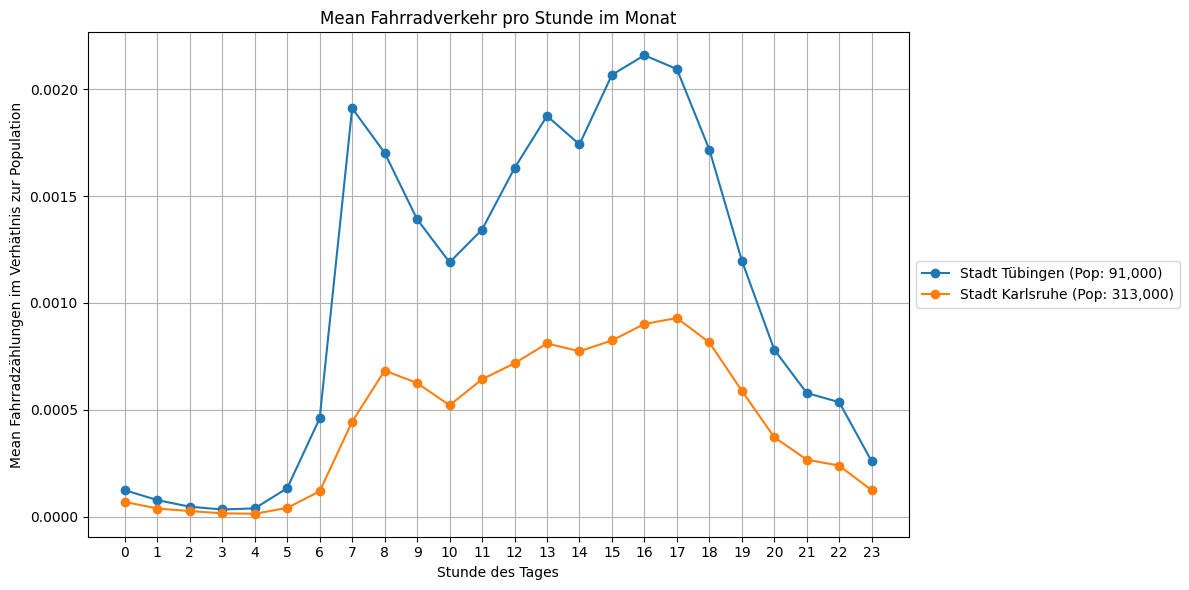

In [57]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))
population = {
    "Stadt Tübingen": 91000,
    "Stadt Karlsruhe": 313000
}

for city in tue_2025_01_bike["domain_name"].unique():
    if city in population: # Aktuell nur Karlsruhe und Tübingen
        city_data = tue_2025_01_bike[tue_2025_01_bike["domain_name"] == city].copy()
        
        # iso_timestamp in datetime konvertieren
        city_data["iso_timestamp"] = pd.to_datetime(city_data["iso_timestamp"])
        
        city_data["hour"] = city_data["iso_timestamp"].dt.hour
        
        avg_per_hour = city_data.groupby("hour")["channels_all"].mean() / population[city] # gibt ein verhätlmnis zur Population aus
        
        plt.plot(avg_per_hour.index, avg_per_hour.values, marker='o', 
                 label=f"{city} (Pop: {population[city]:,})")

plt.xticks(range(24))  # 0–23 Uhr
plt.xlabel("Stunde des Tages")
plt.ylabel("Mean Fahrradzählungen im Verhätlnis zur Population")
plt.title("Mean Fahrradverkehr pro Stunde im Monat")
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()